# <center> Git. Основные операции

**Рабочая директория** — файловая система проекта (те файлы, с которыми вы работаете).

**Индекс** — список отслеживаемых Git-файлов и директорий, промежуточное хранилище изменений (редактирование, удаление отслеживаемых файлов).

**Директория .git/** — в этой локальной директории хранятся все данные контроля версий проекта (вся история разработки — коммиты, ветки, теги и пр.).

* git config

Команда ```config``` предназначена для настройки параметров Git на вашем компьютере.

Например, первое, что вам следует сделать после установки Git — указать ваше имя и адрес электронной почты. Это важно, потому что каждый коммит в Git содержит эту информацию и она не может быть далее изменена. Без указания этой информации основные команды Git будут работать, но коммиты будут создаваться без информации об авторе, что может вызвать трудности при совместной работе.

Если вы не сделали этого ранее, когда устанавливали Git, или захотели поменять настройки, рекомендуем сделать это сейчас. Для этого необходимо указать ключ ```--global``` (глобальные изменения) и передать в команду аргументы user.name и user.email:

```python
git config --global user.name "Your Name"
git config --global user.email "your_email@whatever.com"
    

Примечание. Следующая команда выведет список всех ваших настроек, включая имя и почту:

```python
git config –-list

------

* git init

Данная команда инициализирует локальный репозиторий. По сути, она создаёт пустой репозиторий на вашем компьютере.

---

* git clone

Команда clone — другой вариант инициализации репозитория из уже существующего с помощью копирования. Её общий синтаксис:
``` python
git clone [ссылка на репозиторий]

Данная операция пригодится вам, если все файлы вашего проекта уже где-то существуют.
Клонировать можно как локальный (находящийся на вашем компьютере), так и удалённый (находящийся на GitHub) репозиторий.

---

* git add

Команда add добавляет файл (папку с файлами) в индекс (иногда говорят «индексирует»), то есть добавляет его в список отслеживаемых для системы контроля версий. Нужно указать в аргументах, какой файл или папку мы хотим добавить.

Примеры:
* git add README.md — добавляет файл README.md в индекс.
* git add data/ — добавляет папку data и всё её содержимое в индекс.

Чаще всего нам нужно добавить все файлы в текущем каталоге в индекс (кроме игнорируемых, о которых мы поговорим ниже). Для этого используется команда
* git add .

-----

* git reset

позволяет убрать файлы (папки с файлами) из списка отслеживаемых.

Примеры:
* git reset README.md — удаляет файл README.md из индекса.
* git reset data/ — удаляет папку data из индекса.

Чтобы убрать из индекса все файлы из текущей директории, используйте точку:
* git reset .

-------

* git commit

Коммит — это операция сохранения набора изменений, сделанного в рабочей директории с момента предыдущего коммита. Коммит неизменен, его нельзя отредактировать — можно только отменить.

Команда commit откроет текстовый редактор для ввода сообщения коммита. Также эта команда принимает несколько аргументов:
* -m позволяет написать сообщение вместе с командой, не открывая текстовый редактор.
Обычно в сообщении указывается задача, которая решается этим обновлением, например «инициализация», «добавление счетов» или «исправление ошибки создания счёта».

Пример:
``` python
git commit -m "fixed bag in function clean_data"
```
* -a переносит все отслеживаемые файлы в область подготовленных файлов и включает их в коммит.

Пример:
``` python
git commit -a -m "fixed bag in function clean_data"
```
* --amend заменяет последний коммит новым изменённым коммитом, что бывает полезно, если вы неправильно набрали сообщение последнего коммита или забыли включить в него какие-то файлы.


Каждый коммит содержит уникальную контрольную сумму (хеш) — идентификатор, который Git использует, чтобы ссылаться на коммит. Для отслеживания истории в папке .git есть файл ```HEAD```.

**HEAD** — это указатель (то есть ссылка на один из коммитов), главное назначение которого — определять, в каком состоянии находится рабочая директория. На какой коммит указывает ```HEAD```, в таком состоянии файлы и находятся в рабочей области.

Зная **HEAD** (текущий действующий коммит), мы можем перемещаться по истории коммитов.

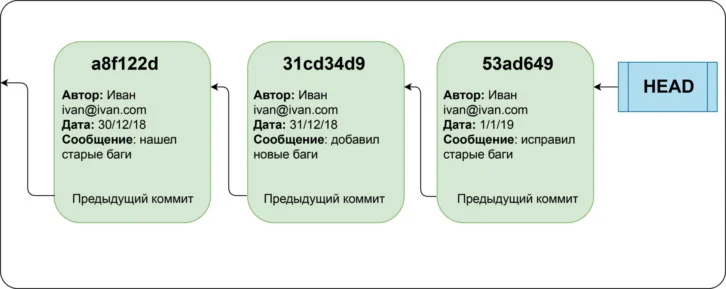

Чтобы посмотреть, на какой из коммитов указывает HEAD в данный момент, можно открыть файл HEAD в текстовом редакторе или использовать команду ```cat-file с ключом -p``` (от слова print). Пример:
``` python
git cat-file -p HEAD
```

-----

## <center> ПОЛУЧЕНИЕ ДАННЫХ О СОСТОЯНИИ РЕПОЗИТОРИЯ

* git status

Данная команда позволяет отследить состояние файлов в репозитории и узнать, какие изменения необходимо зарегистрировать Git (при необходимости — отменить).

Файл в репозитории может находиться в нескольких состояниях:

1. Отслеживаемый. Это те файлы, о которых Git знает и отслеживает изменения в них. Отслеживаемые файлы в свою очередь могут находится в следующих состояниях:

* Неизменённый. То есть с момента последнего коммита в файле не было никаких изменений.
* Изменённый. То есть с последнего коммита в файле были произведены какие-то изменения.
* Подготовленный к коммиту. Это значит, что вы внесли изменения в этот файл и затем проиндексировали файлы с внесёнными изменениями. Полученные изменения будут добавлены в следующий коммит.
2. Неотслеживаемый. О неотслеживаемых файлах Git не знает, поэтому изменения в них не будут добавлены в коммит. Это любые файлы в вашем рабочем каталоге, которые не входили в последний коммит и не подготовлены к текущему коммиту.

Можно вывести более сжатую версию этой информации, воспользовавшись командой^
```python
git status -s
```

------

* git log

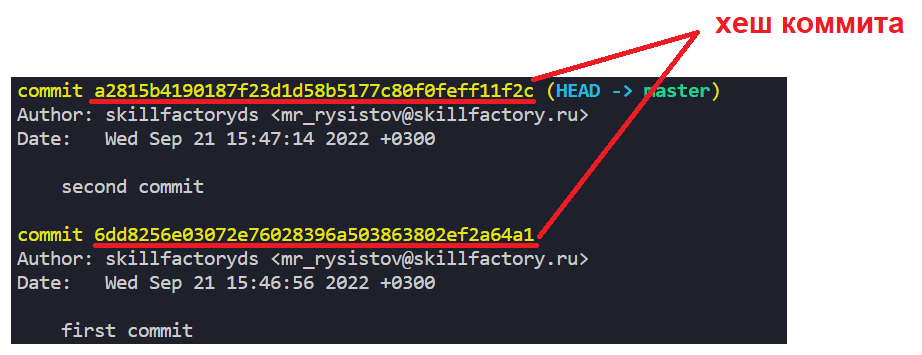

Примечание. Чтобы выйти из режима логирования, необходимо нажать "q".

------

* git show

Выполнив эту команду, вы увидите на экране информацию по определённому коммиту: кто сделал этот коммит, когда это произошло, сообщение коммита, а также сами изменения. Общий синтаксис команды:
```python
git show [хеш коммита]
```

В выводе команды show содержится информация об авторе коммита, дате коммита, а также обо всех изменениях в каждом из файлов. Просмотр изменений осуществляется в режиме текстового редактора.

Примечание. Свернуть окно просмотра после команды show можно с помощью символа "q".

---

### <center> ПЕРЕМЕЩЕНИЕ МЕЖДУ КОММИТАМИ И ОТКАТ ИЗМЕНЕНИЙ

* git checkout

Зная хеши коммитов и их историю, мы можем перемещаться между ними, то есть возвращаться к состоянию файлов в нашем проекте, зафиксированному тем или иным коммитом. В этом нам поможет команда checkout. Её общий синтаксис:
```python
git checkout [хеш коммита]
```

С точки зрения системы Git перемещение между коммитами (без дополнительных ключей) — это не что иное, как передвижение указателя HEAD.

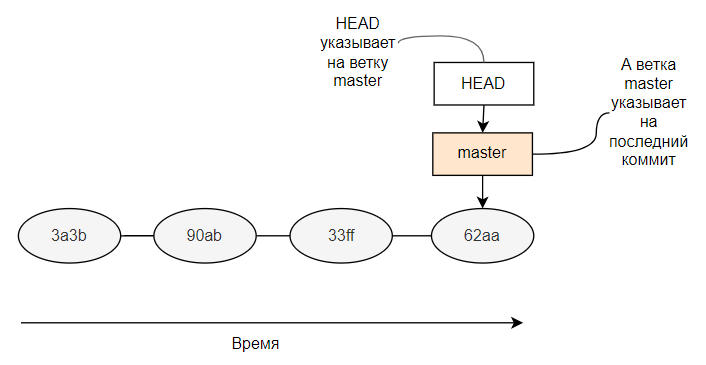

Серыми овалами обозначены коммиты (их четыре), текст на них — часть хеша соответствующего коммита. Коричневым прямоугольником обозначен указатель ветки: на приведённом примере она одна и называется master. Белым прямоугольником обозначен указатель HEAD — его-то мы и будем двигать.

Чтобы перейти к определённому коммиту, вам нужно лишь передать его хеш в качестве параметра команды checkout. Например:
```python
git checkout 90ab
```

Примечание. Для перемещения по коммитам можно использовать относительный путь. Для этого используются операторы ~ (назад по истории коммитов) и ^ (вперёд по истории коммитов), то есть предыдущую команду можно записать как:
```python
git checkout HEAD~2
```

То есть Git выдаёт предупреждение, что мы находимся в некотором состоянии, именуемом “detached head” (дословно — «отрубленная голова»). Схематично его можно изобразить так:

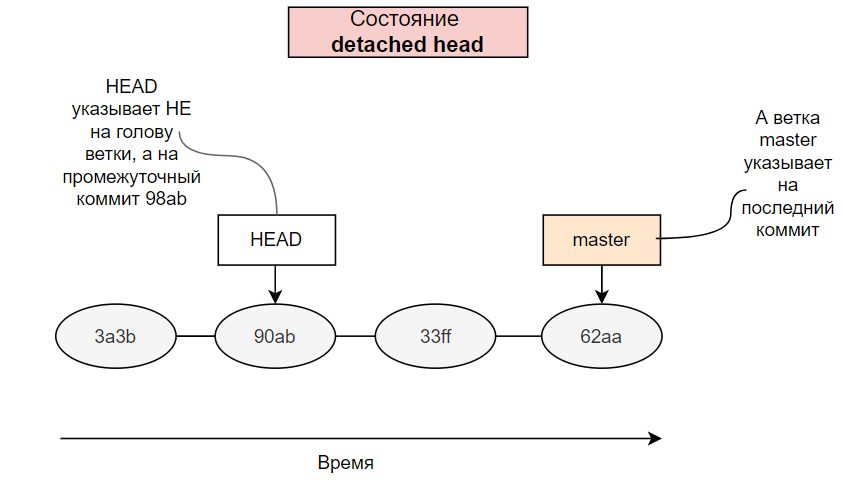

Как видно из рисунка, указатель HEAD действительно передвинут на два коммита назад. Однако указатель ветки master остался на месте и всё ещё указывает на последний коммит. Такое состояние, когда HEAD указывает не на указатель ветки, а непосредственно на сам коммит, как раз и называется detached head.

Зачем может понадобиться команда checkout?

В целом состояние detached head, которое даёт команда checkout при перемещении по коммитам, используется довольно редко. Однако всё же можно привести несколько примеров:

Самый простой пример — просмотр состояния файлов в определённом коммите.

Представим, что мы наделали ошибок в нашем проекте, причём так, что быстро переписать код уже не получится. Поэтому мы хотим откатиться назад, на одну из предыдущих версий. Однако мы не помним, какой коммит соответствует устраивающей нас версии. Тут нам и поможет checkout.

Мы можем перемещаться по истории коммитов и найти то состояние файлов, которое нас устраивает. Когда мы его найдём, нам останется вернуться на исходную позицию — переместить указатель HEAD на ветку master, а затем откатиться до интересующего нас коммита.

Кроме того, когда вы работаете над большим проектом, может возникнуть необходимость вернуться на несколько коммитов назад и создать свою ветку оттуда, например чтобы протестировать экспериментальную функцию в том состоянии проекта. О том, как создавать ветки, мы поговорим далее.

------

* git revert

Ваш проект может перестать работать после внесения изменений в код. В таком случае важно уметь быстро вернуть всё к рабочему состоянию и только потом заниматься поиском ошибки. Для этого как раз и нужна команда ```revert```.

Данная команда создаёт новый коммит, который отменяет изменения, внесённые в переданном коммите (последовательности коммитов). То есть для отмены изменений создаётся новый коммит, который «стирает» тот, который мы укажем в аргументах.

Например, команда ```git revert 62aa``` создаст новый коммит, который отменяет изменения, сделанные в коммите ```62aa```. Если мы просто выполним данную команду, будет открыт консольный редактор, чтобы вы могли отредактировать сообщение нового коммита. Можно что-то дописать, можно сразу закрыть редактор (комбинация клавиш ":" и "q"), а можно воспользоваться ключом ```--no-edit``` и оставить сообщение нового коммита по умолчанию (рекомендуется).

```python
git revert 62aa --no-edit
git revert HEAD --no-edit #отмена изменений в текущем коммите
git revert HEAD~1 --no-edit #отмена изменений в предыдущем коммите

----------

## <center> ФAЙЛ .GITIGNORE

* Описание файла

Файл с описанием файлов, для которых не должно вестись отслеживание версий, имеет расширение ```.gitignore```.
Файл ```.gitignore``` представляет собой простой текстовый файл с перечнем шаблонов файловых имён, которые не должны отслеживаться.

Основные правила синтаксиса этого файла:
* одна строка — один шаблон;
* пустые строки игнорируются;
* чтобы написать комментарий, в начале строки укажите знак #, закомментированные строки не рассматриваются.

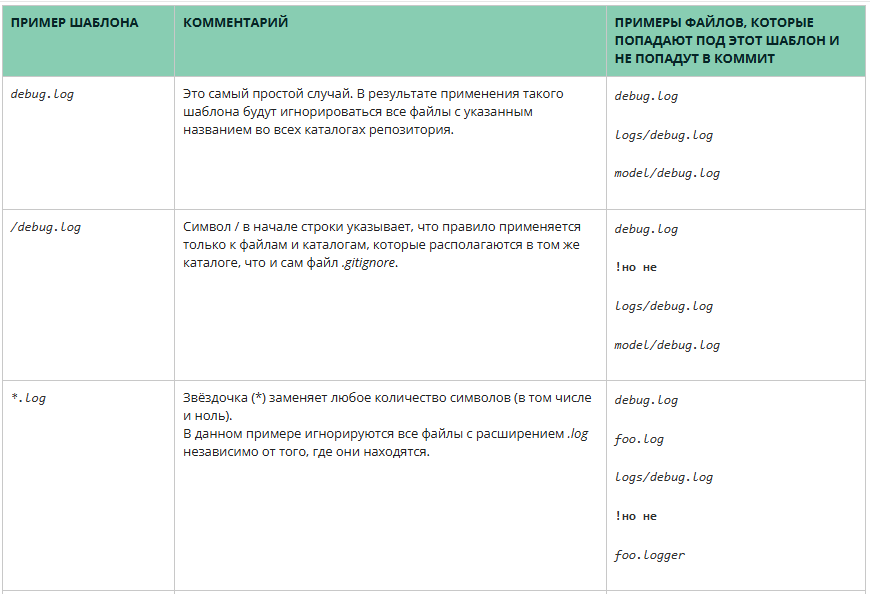

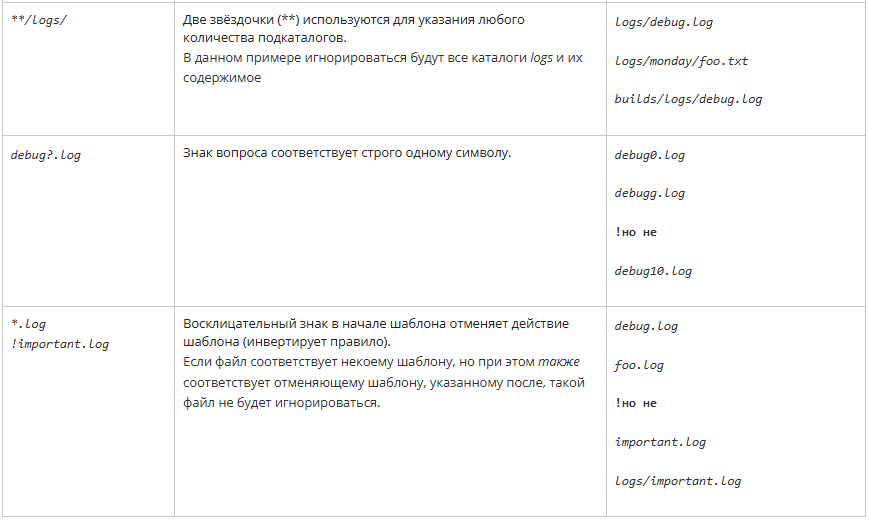

[список всех шаблонов](https://routerus.com/gitignore-ignoring-files-in-git/)

В проекте может быть любое количество файлов .gitignore, однако обычно достаточно одного в корневой папке проекта

**Примечание.** Иногда возможна ситуация, что вы уже закоммитили файлы, которые стоило добавить в .gitignore. Чтобы игнорировать файл, для которого ранее был сделан коммит, необходимо удалить этот файл из репозитория, а затем добавить для него правило в .gitignore.

Можно использовать команду ```git rm```ёёё с параметром ```--cached```, чтобы удалить этот файл из репозитория, но оставить его в рабочем каталоге как игнорируемый.

Например, следующая команда удаляет файл debug.log из коммита:
```python
git rm --cached debug.log
```

После этого вы можете внести этот файл в .gitignore и сделать новый коммит.

---------

### <center> РАБОТА С УДАЛЁННЫМ РЕПОЗИТОРИЕМ

* git remote add

```python
git remote add [имя удалённого репозитория] [ссылка]
```

Имя удалённого репозитория в команде remote add вы можете придумать самостоятельно. Заданное имя вы будете использовать впоследствии при работе с репозиторием. Традиционно удалённый репозиторий носит имя origin, однако никаких ограничений здесь нет.

Со ссылкой на удалённый репозиторий тоже всё просто: мы работаем с GitHub, поэтому эту ссылку можно получить, нажав на большую зелёную кнопку Code на странице репозитория на GitHub.

Существует несколько вариантов подключения к удалённому репозиторию:
* HTTPS-ссылка,
* SSH-ссылка,
* GitHub CLI-ссылка.

```git remote add origin https://github.com/SkillfactoryDS/DataCleaningProject.git```

----------

* git remote remove

Раз есть возможность подключить удалённый репозиторий и добавить его в список связанных, значит, должна быть возможность и отключить его. Для этого предназначена команда remote remove. Её синтаксис:

```python
git remote remove [имя удалённого репозитория]
```

--------

* git push

Операция push производит отправку локальных изменений из текущей ветки в удалённый репозиторий. Общий синтаксис команды:

```python
 git push [имя удалённого репозитория][имя ветки]
 ```

``` git push origin master```

----------

* git fetch

Данная команда используется для получения изменений с удалённого репозитория. Важно отметить, что при этом приходит список изменений, но они не вносятся в код, используемый в локальном репозитории.

Общий синтаксис:

```pythion
git fetch [имя удалённого репозитория]
```

```git fetch origin```

В результате выполнения данной команды на вашем компьютере будет создана новая удалённая ветка origin/master. Чтобы посмотреть, какие изменения были совершены в удалённом репозитории, можно воспользоваться уже знакомой вам командой checkout. Она позволит переключиться на новую ветку:

``` git checkout origin/master```

---------

* git merge

Операция merge используется для слияния полученных с помощью команды fetch изменений и текущей ветки локального репозитория. О слиянии веток мы поговорим отдельно в следующем юните.

Пример получения и слияния изменений из удалённого репозитория:

```python
git fetch origin
git merge origin/master
```

После выполнения этих команд все изменения, которые зафиксированы в удалённом репозитории, вступят в силу в локальном.

---------

* git pull

На самом деле, если вы уверены в изменениях в удалённом репозитории, то можете сразу получить эти изменения и объединить их с локальным репозиторием. Для этого предназначена операция pull. По умолчанию она эквивалентна последовательному выполнению команд git fetch и git merge.

Общий синтаксис команды:

```python
git pull [имя удаленного репозитория] [имя ветки]
```

```git pull origin master```

На практике, конечно же, команда pull используется намного чаще, чем связка fetch и merge

----------

## <center> Git. Ветвление и конфликты

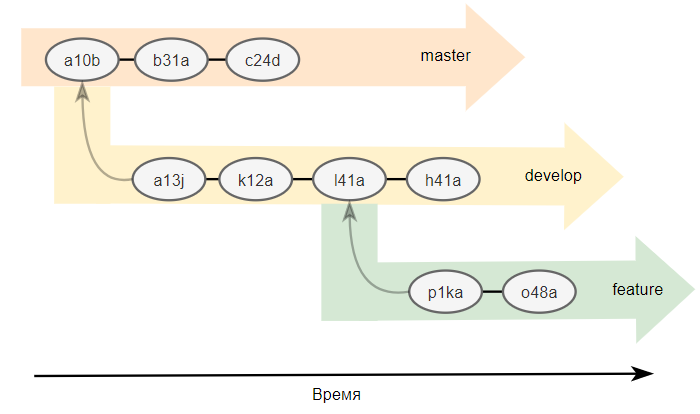

``` git fetch origin

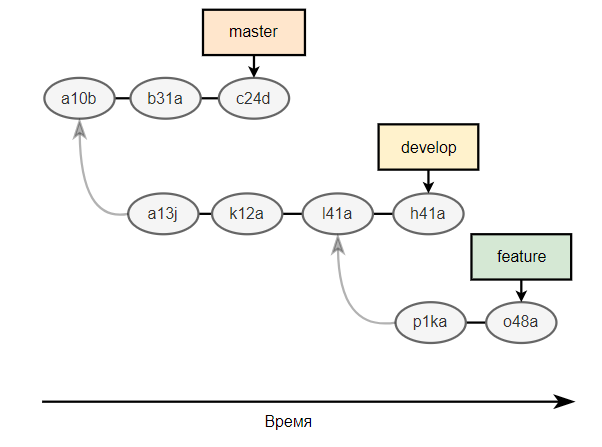

При командной разработке нередко приходится создавать определённый функционал отдельно от основного проекта.
Создание различных версий репозиториев, отличных друг от друга, и называется ветвлением.

### СОЗДАНИЕ ВЕТКИ И ПЕРЕКЛЮЧЕНИЕ НА ВЕТКУ

* git branch

Как мы уже говорили ранее, как только вы создаёте свой первый коммит, Git создаёт основную ветку master. Тем не менее, мы можем создавать собственные ветки и переключаться между ними.

Для создания ветки можно использовать команду branch. Её полный синтаксис:

```python
git branch [наименование ветки]
```
Например, следующая команда создаст ветку с именем develop:

```git branch develop```

Для удаления ветки используется та же самая команда branch, но с ключом -D. Например, следующая команда удалит ветку с именем develop:

```python
git branch -D develop
```

---------

* git checkout

Это уже знакомая нам команда. Ранее мы использовали её для переключения между коммитами: с её помощью мы перемещаем указатель текущего состояния HEAD на заданный коммит. Однако точно так же можно перемещать указатель на определённую ветку, ведь выше мы отметили, что указатель на ветку — это указатель на последний коммит в ней.

Например, следующее сочетание команд создаёт ветку dev и переключает нас на неё:
```python
git branch develop
git checkout develop
```

На самом деле эту запись можно сократить до одной команды. Оказывается, команда checkout может самостоятельно создавать ветку и сразу переключаться на неё. Для этого достаточно указать ключ -b. Это намного удобнее, чем выполнять два этих действия по отдельности. Поэтому данный способ является более предпочтительным. Пример:
```python
git checkout -b develop
```

**Важное замечание**: как только вы создали новую ветку с помощью команды branch, она указывает на тот же коммит, что и основная ветка, из которой вы работали ранее, и HEAD.

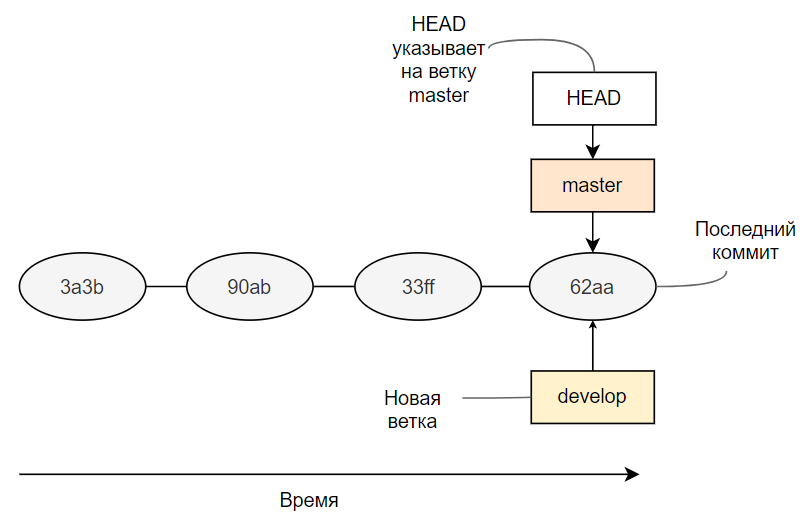

Если же вы переключитесь на новую ветку (используя команду checkout), поработаете в ней, внесёте какие-то изменения и сделаете несколько коммитов, то ситуация будет выглядеть вот так:

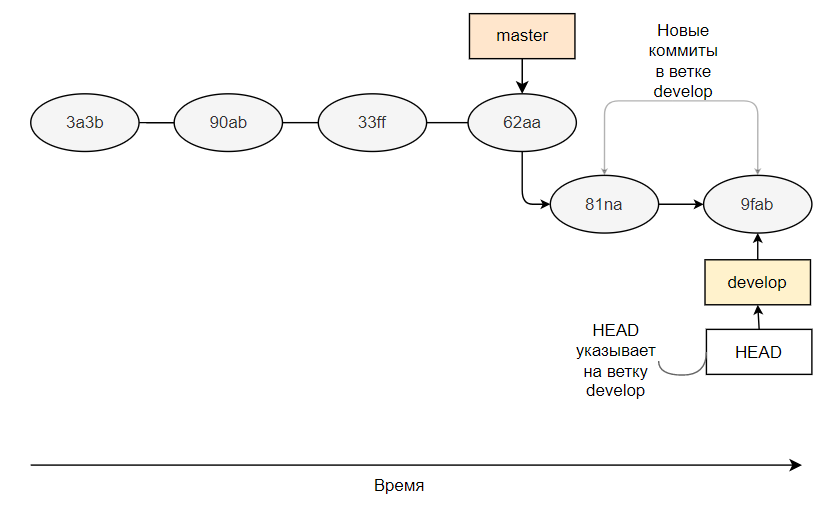

Видно, что указатель ветки develop и указатель текущего состояния HEAD передвинулись на последний коммит 9fab. При этом важно отметить, что так как и ветка, и HEAD указывают на одно и то же, то состояния “detached head” не возникает.

---

## ПРОСМОТР СПИСКА ВЕТОК И ИХ СОСТОЯНИЙ

Когда в проекте много веток, существует вероятность, что вы забудете их имена, а без знания имени ветки работать с ней у вас не получится. Для просмотра списка веток используется всё та же команда branch.

Можно просто вызвать команду из терминала, и она выведет список всех локальных веток. Например:

git branch
* master
* develop

Однако можно добавить ключи:

-r (от англ. remote). Добавив этот ключ в команду branch, вы сможете вывести список только удалённых веток (тех, которые находятся в удалённом репозитории). Пример:

git branch -r
* origin/master

-a. С этим ключом выводятся все ветки — как локальные, так и удаленные. Пример:

git branch -a
* master 
* develop
* remotes/origin/master

Для просмотра состояния файлов, информации по истории коммитов и изменений, которые в них были произведены в текущей ветке, используются те же самые команды status, log и show, которые мы изучали ранее.

-------

## СЛИЯНИЕ ВЕТОК

**Слияние веток** — это процесс переноса изменений из одной ветки в другую. При этом слияние не затрагивает сливаемую ветку (ту, из которой мы берём изменения), то есть она остаётся в том же состоянии, что позволяет нам потом продолжить работу с ней. Ветка, в которую сливаются все изменения, называется **целевой**.

* git merge

Данная команда вносит коммиты из другой ветки в текущую. Её синтаксис имеет вид:
```python
git merge [имя сливаемой ветки]
```

В Git существует две стратегии слияния — неявное и явное. Давайте рассмотрим их различия.

В случае **неявного слияния** (используется по умолчанию) не создаётся никаких новых коммитов — используются только уже существующие. Идея такого слияния заключается в том, что из вливаемой ветки извлекается несколько коммитов, а затем они применяются к последнему коммиту целевой ветки. Такое слияние называется **fast-forward**.

Пример выполнения неявного fast-forward-слияния для случая нашего репозитория из примера выше:
```python
git checkout master
git merge develop
```

Что происходит в результате выполнения этих команд?

1. Проверяется, что в ветке master отсутствуют коммиты, сделанные после ответвления develop.
2. Проверяется, что не возникает конфликтов слияния (о них мы поговорим ниже).
3. Переносится указатель master на коммит 9fab.
Теперь ветка develop как бы стала веткой master.
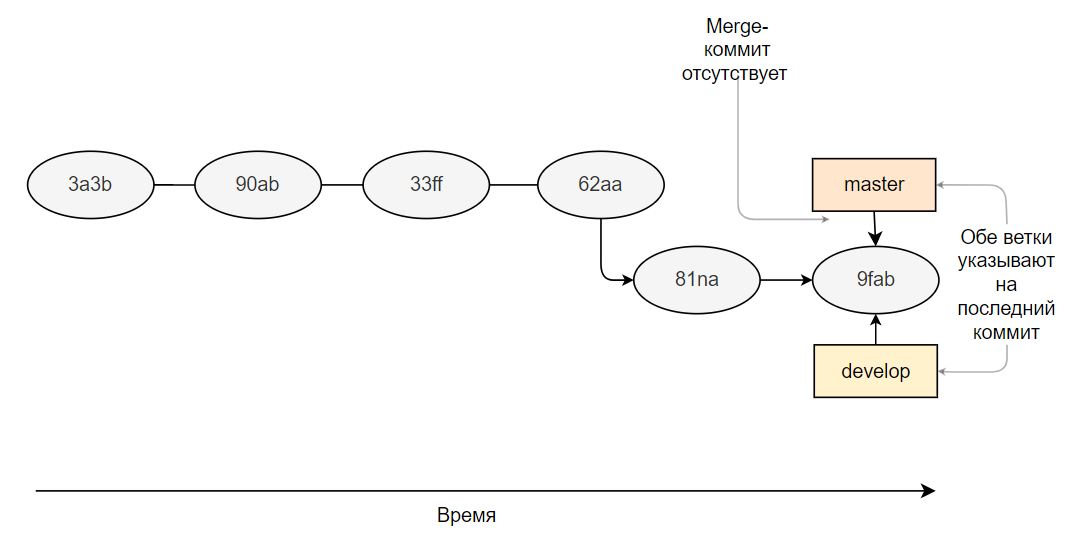

В случае **явного слияния** (оно задаётся с помощью ключа ```no-ff```) всегда создаётся новый так называемый merge-коммит, который «объединяет» изменения двух веток. У этого коммита есть особенность — два родительских коммита: первый родитель — последний коммит сливаемой ветки, второй — последний коммит целевой ветки.

Пример выполнения явного **no-fast-forward-слияния** для случая нашего репозитория из примера выше:
```python
git checkout master
git merge –-no-ff develop
```

Что происходит в результате выполнения этих команд?

1. Проверяется, нет ли конфликтов слияния. Если возникает конфликт, выполнение команды git merge останавливается, чтобы получить инструкции от пользователя (об этом мы поговорим ниже).
2. Все изменения из коммитов 81na и 9fab добавляются в индекс ветки master.
3. Выполняется коммит.
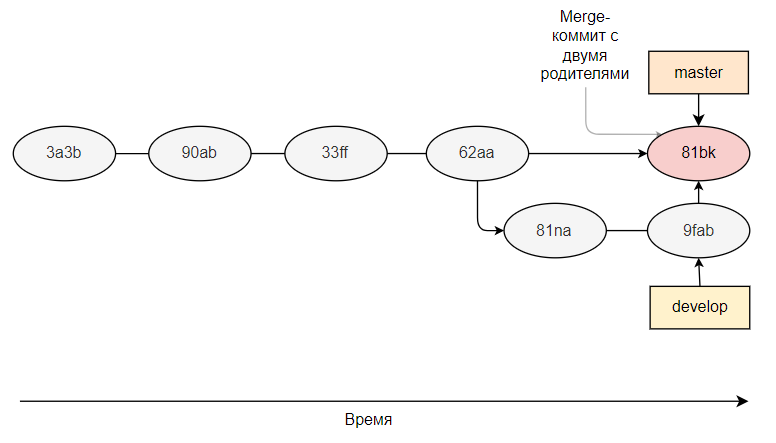

Режим fast-forward используется по умолчанию (без дополнительных ключей) и считается более удобным, поскольку он не подразумевает создания лишних merge-коммитов, засоряющих историю репозитория. С другой стороны, если мы захотим продолжить пользоваться веткой develop после fast-forward-слияния, потом будет довольно трудно разобраться в её истории. Поэтому, выполняя слияние, задумайтесь, хотите ли вы, чтобы оно прошло в режиме fast-forward, или лучше явно создать merge-коммит, собирающий всё воедино.

-----------

### <center> КУЛЬТУРА КОММИТОВ

Правильное написание коммитов приходит с опытом, но уже сейчас, соблюдая несколько простых правил, вы сможете писать сообщения коммитов на уровне профессионала:

1. Текст коммита формируется из трёх частей:
* действие (добавление, исправление, рефакторинг и т. д.);
* сущность (документация, новая модель, главная страница и т. д.);
* подробности (задача №23, несуществующий пользователь, зависимости и т. д.) — необязательное поле.
2. Полнота — не многословие. Старайтесь давать достаточную информацию об изменениях, но стоит избегать излишних подробностей.
3. Используйте в коммитах английский язык. В русскоязычных командах допускаются коммиты на русском языке, но это не лучшая практика, так как ограничивает аудиторию проекта.
4. Найдите свой стиль. Необязательно изобретать велосипед. Ознакомьтесь с различными практиками, соблюдайте требования команды.
5. Есть слова, которые уже воспринимаются разработчиками как определённые действия:
* init — инициализация;
* add — добавление;
* delete — удаление;
* update — изменение;
* fix — исправление;
* refactor — рефакторинг кода приложения;
* style — исправление опечаток, форматирования;
* docs — всё, что касается документации;
* test — всё, что связано с тестированием;
* merged, fix conflict — слияние, решение конфликта.